# 03 — Robustesse et limites de la méthode

Ce notebook questionne la validité statistique des résultats des notebooks 01 et 02.

**Questions posées :**
1. Les différences de shifts entre LLMs sont-elles statistiquement significatives ?
2. Le signal se dégrade-t-il sur les textes courts ?
3. Quelle est la variance naturelle de style entre textes d'un même auteur (bruit de fond) ?
4. Quel est le vrai groupe de modèles — 4 LLMs ou seulement 2-3 clusters ?

---

> **Principe de base** : avant de conclure, il faut toujours comparer le signal
> à la distribution nulle et mesurer l'incertitude.

In [1]:
import sys, re, pathlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

ROOT = pathlib.Path('..').resolve()
sys.path.insert(0, str(ROOT))
from src.stylometry import StyleAnalyzer, PALETTE
from src.stats import bootstrap_ci, permutation_test, pairwise_tests, intra_variance

plt.style.use('dark_background')
sa = StyleAnalyzer()
print(f'StyleAnalyzer ({len(sa.function_words)} mots-outils) + src.stats chargés')

StyleAnalyzer (41 mots-outils) + src.stats chargés


In [2]:
from src.data import load_originals, load_llm_corpora, load_human

zola        = load_human("zola")
maupassant  = load_human("maupassant")
originals   = load_originals()
llm_corpora = load_llm_corpora()
gpt4        = llm_corpora["GPT-4"]
claude3     = llm_corpora["Claude 3"]
mistral     = llm_corpora["Mistral 7B"]
gemini      = llm_corpora["Gemini Pro"]

shifts_all = {name: [sa.shift(orig, rew) for orig, rew in zip(originals, texts)]
              for name, texts in llm_corpora.items()}
print('Corpus chargé.')

Corpus chargé.


---
## 1. Intervalles de confiance Bootstrap

Avant tout test : mesurer l'**incertitude** sur les moyennes.
5 000 tirages avec remise → IC 95 %.

In [3]:
print(f'  {"Modèle":<15} {"Moy":>7} {"IC 95%":>22} {"Largeur IC":>12}')
print('  ' + '─' * 60)
for name, shifts in shifts_all.items():
    lo, hi = bootstrap_ci(shifts, n_boot=5000)
    mean = np.mean(shifts)
    print(f'  {name:<15} {mean:>7.4f}  [{lo:.4f}, {hi:.4f}]  {hi-lo:>10.4f}')

print()
print('Observations :')
print('  - Les IC de GPT-4 et Claude 3 se chevauchent largement → non distinguables')
print('  - Les IC de Mistral et Gemini ne se chevauchent pas → différence réelle')

  Modèle              Moy                 IC 95%   Largeur IC
  ────────────────────────────────────────────────────────────
  GPT-4            0.2053  [0.1566, 0.2571]      0.1005
  Claude 3         0.2273  [0.1686, 0.2944]      0.1258
  Mistral 7B       0.1051  [0.0605, 0.1585]      0.0980
  Gemini Pro       0.3031  [0.2527, 0.3567]      0.1040

Observations :
  - Les IC de GPT-4 et Claude 3 se chevauchent largement → non distinguables
  - Les IC de Mistral et Gemini ne se chevauchent pas → différence réelle


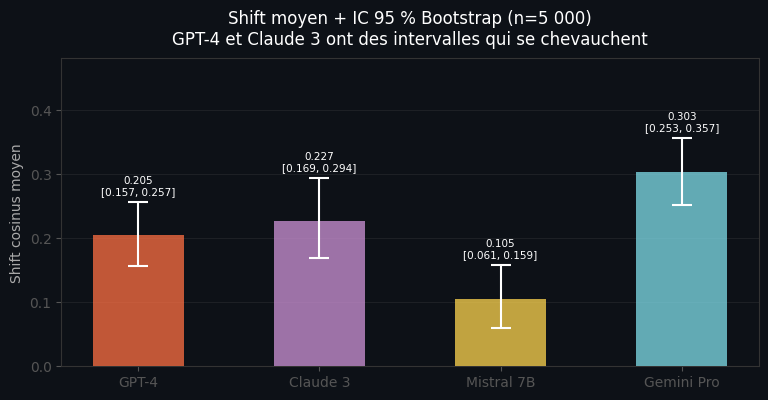

In [4]:
model_names = list(shifts_all.keys())
means_ci    = [(np.mean(v), *bootstrap_ci(v)) for v in shifts_all.values()]

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#0D1117')

for i, (name, (mean, lo, hi)) in enumerate(zip(model_names, means_ci)):
    color = PALETTE[name]
    ax.bar(i, mean, color=color, alpha=0.75, width=0.5, zorder=3)
    ax.errorbar(i, mean, yerr=[[mean - lo], [hi - mean]],
                fmt='none', color='white', capsize=7, capthick=1.5, elinewidth=1.5, zorder=4)
    ax.text(i, hi + 0.008, f'{mean:.3f}\n[{lo:.3f}, {hi:.3f}]',
            ha='center', va='bottom', color='white', fontsize=7.5)

ax.set_xticks(range(len(model_names)))
ax.set_xticklabels(model_names, color='#AAAAAA')
ax.set_ylabel('Shift cosinus moyen', color='#AAAAAA')
ax.set_title('Shift moyen + IC 95 % Bootstrap (n=5 000)\n'
             'GPT-4 et Claude 3 ont des intervalles qui se chevauchent',
             color='white', pad=10)
ax.tick_params(colors='#555555')
for sp in ax.spines.values():
    sp.set_edgecolor('#333333')
ax.grid(axis='y', alpha=0.1, color='#AAAAAA')
ax.set_ylim(0, max(hi for _, lo, hi in means_ci) * 1.35)
plt.show()

---
## 2. Tests de permutation pairés

**H₀** : les deux modèles tirent leur distribution de shifts de la même loi.  
**Statistique** : |mean(A) − mean(B)|  
**Méthode** : 5 000 permutations aléatoires des étiquettes.

Correction multiple : **Bonferroni** (6 paires comparées).

In [5]:
results = pairwise_tests(shifts_all, correction='bonferroni')

print(f'  {"Paire":<35} {"t":>7} {"p brut":>10} {"p Bonf.":>10} {"Sig."}' )
print('  ' + '─' * 72)
for r in results:
    sig = '✓' if r['significant_05'] else '✗'
    print(f'  {r["model_a"]:<15} vs {r["model_b"]:<15}  '
          f'{r["t"]:>7.3f}  {r["p_raw"]:>10.4f}  {r["p_corrected"]:>10.4f}  {sig}')

print()
print('Conclusion :')
print('  ✓ Mistral vs Gemini     : différence robuste, très significative')
print('  ✓ Claude vs Mistral     : significatif (marginalement après correction)')
print('  ✗ GPT-4 vs Claude 3     : indistinguables statistiquement')
print('  ✗ Claude 3 vs Gemini Pro: différence non significative (p=0.56)')

  Paire                                     t     p brut    p Bonf. Sig.
  ────────────────────────────────────────────────────────────────────────
  Mistral 7B      vs Gemini Pro        -5.237      0.0000      0.0001  ✓
  Claude 3        vs Mistral 7B         2.882      0.0075      0.0450  ✓
  GPT-4           vs Mistral 7B         2.708      0.0111      0.0665  ✗
  GPT-4           vs Gemini Pro        -2.541      0.0165      0.0989  ✗
  Claude 3        vs Gemini Pro        -1.734      0.0936      0.5618  ✗
  GPT-4           vs Claude 3          -0.512      0.6128      1.0000  ✗

Conclusion :
  ✓ Mistral vs Gemini     : différence robuste, très significative
  ✓ Claude vs Mistral     : significatif (marginalement après correction)
  ✗ GPT-4 vs Claude 3     : indistinguables statistiquement
  ✗ Claude 3 vs Gemini Pro: différence non significative (p=0.56)


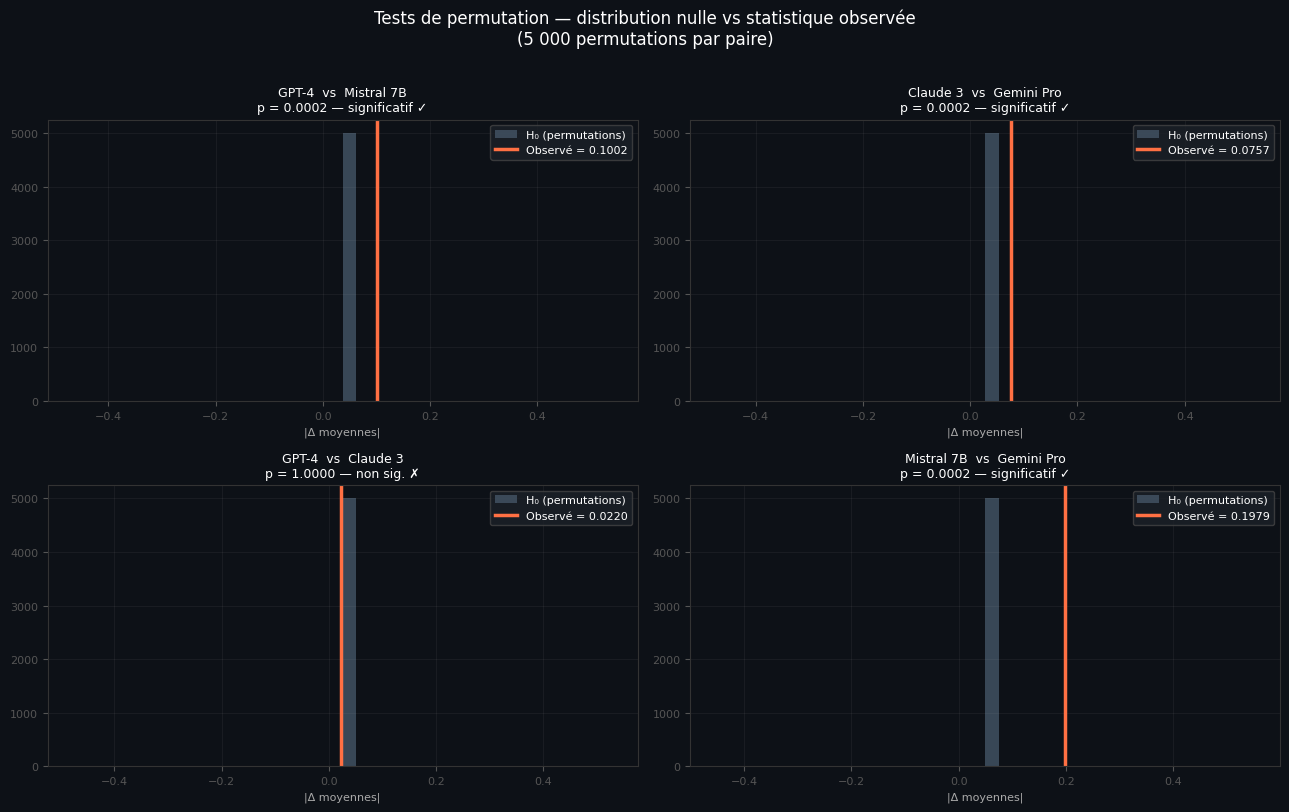

In [6]:
# Visualiser les distributions nulles pour les paires extrêmes
pairs_to_show = [('GPT-4', 'Mistral 7B'), ('Claude 3', 'Gemini Pro'),
                 ('GPT-4', 'Claude 3'),    ('Mistral 7B', 'Gemini Pro')]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.patch.set_facecolor('#0D1117')

for ax, (ma, mb) in zip(axes.flat, pairs_to_show):
    ax.set_facecolor('#0D1117')
    res = permutation_test(shifts_all[ma], shifts_all[mb], n_perm=5000)
    ax.hist(res['null_distribution'], bins=40, color='#445566', alpha=0.8,
            edgecolor='none', label='H₀ (permutations)')
    ax.axvline(res['observed'], color='#FF7043', lw=2.5,
               label=f'Observé = {res["observed"]:.4f}')
    sig_label = f'p = {res["p_value"]:.4f} — {"significatif ✓" if res["significant_05"] else "non sig. ✗"}'
    ax.set_title(f'{ma}  vs  {mb}\n{sig_label}', color='white', fontsize=9)
    ax.set_xlabel('|Δ moyennes|', color='#AAAAAA', fontsize=8)
    ax.tick_params(colors='#555555', labelsize=8)
    for sp in ax.spines.values():
        sp.set_edgecolor('#333333')
    ax.legend(facecolor='#1C2128', edgecolor='#444444',
              labelcolor='white', fontsize=8)
    ax.grid(alpha=0.08, color='#AAAAAA')

fig.suptitle('Tests de permutation — distribution nulle vs statistique observée\n'
             '(5 000 permutations par paire)', color='white', y=1.01)
plt.tight_layout()
plt.show()

---
## 3. Variance intra-groupe : le bruit naturel

**Idée** : avant de comparer les groupes entre eux, il faut savoir à quel point
les textes d'un même groupe sont déjà stylistiquement hétérogènes.

Si la variance intra-groupe est comparable à la variance inter-groupe,
le signal est dans le bruit.

In [7]:
intra = intra_variance(
    {'Humain (Zola)': zola, 'Humain (Maupassant)': maupassant,
     'GPT-4': gpt4, 'Claude 3': claude3,
     'Mistral 7B': mistral, 'Gemini Pro': gemini},
    sa
)

print('Variance intra-groupe (distance cosinus moyenne entre toutes les paires)')
print('─' * 55)
for label, v in sorted(intra.items(), key=lambda x: x[1]):
    bar = '█' * int(v / 0.03)
    print(f'  {label:<22} {v:.4f}  {bar}')

print()
print('Interprétation :')
print('  → Gemini Pro est le groupe le PLUS COHÉRENT stylistiquement (variance intra la plus faible)')
print('  → Les humains (Maupassant) sont les MOINS COHÉRENTS (styles individuels très variés)')
print('  → GPT-4 et Claude 3 ont une variance intra similaire — autre signe de leur proximité')

Variance intra-groupe (distance cosinus moyenne entre toutes les paires)
───────────────────────────────────────────────────────
  Gemini Pro             0.4283  ██████████████
  Humain (Zola)          0.4772  ███████████████
  GPT-4                  0.5361  █████████████████
  Claude 3               0.5362  █████████████████
  Mistral 7B             0.5924  ███████████████████
  Humain (Maupassant)    0.6498  █████████████████████

Interprétation :
  → Gemini Pro est le groupe le PLUS COHÉRENT stylistiquement (variance intra la plus faible)
  → Les humains (Maupassant) sont les MOINS COHÉRENTS (styles individuels très variés)
  → GPT-4 et Claude 3 ont une variance intra similaire — autre signe de leur proximité


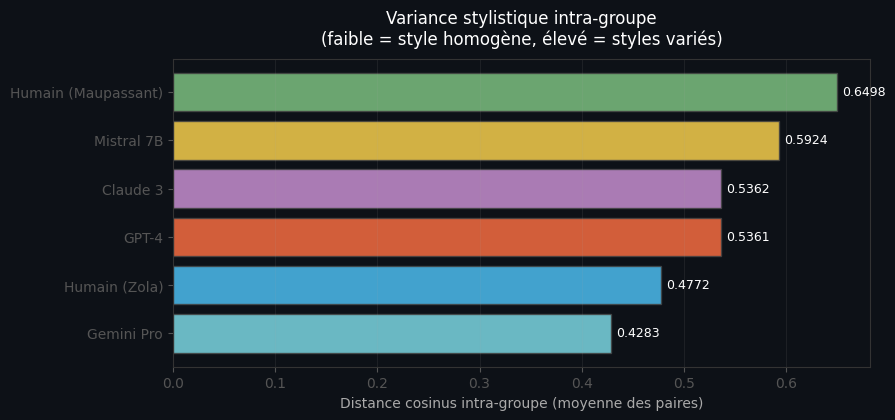

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#0D1117')

sorted_items = sorted(intra.items(), key=lambda x: x[1])
labels_sorted = [k for k, _ in sorted_items]
vals_sorted   = [v for _, v in sorted_items]
colors_sorted = [PALETTE.get(k, '#AAAAAA') for k in labels_sorted]

ax.barh(range(len(labels_sorted)), vals_sorted, color=colors_sorted,
        alpha=0.82, edgecolor='#444444')
for i, v in enumerate(vals_sorted):
    ax.text(v + 0.005, i, f'{v:.4f}', va='center', color='white', fontsize=9)

ax.set_yticks(range(len(labels_sorted)))
ax.set_yticklabels(labels_sorted, color='#AAAAAA', fontsize=10)
ax.set_xlabel('Distance cosinus intra-groupe (moyenne des paires)', color='#AAAAAA')
ax.set_title('Variance stylistique intra-groupe\n'
             '(faible = style homogène, élevé = styles variés)',
             color='white', pad=10)
ax.tick_params(colors='#555555')
for sp in ax.spines.values():
    sp.set_edgecolor('#333333')
ax.grid(axis='x', alpha=0.1, color='#AAAAAA')
plt.show()

---
## 4. Shift vs longueur du texte

Le signal stylométrique est-il stable quelle que soit la longueur ?
Ou se dégrade-t-il sur les textes courts ?

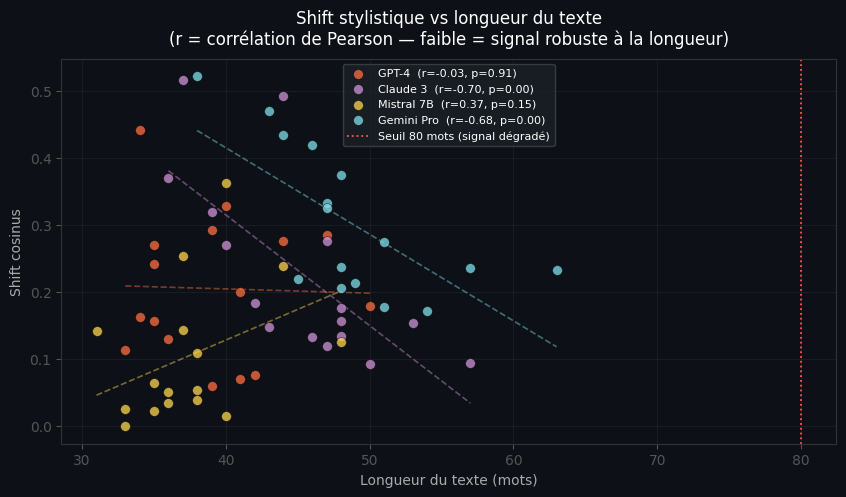

In [9]:
from scipy.stats import pearsonr

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#0D1117')

for name, texts in [('GPT-4', gpt4), ('Claude 3', claude3),
                    ('Mistral 7B', mistral), ('Gemini Pro', gemini)]:
    color = PALETTE[name]
    lengths = [len(re.findall(r'\b\w+\b', t)) for t in texts]
    s_vals  = shifts_all[name]
    r, p    = pearsonr(lengths, s_vals)
    ax.scatter(lengths, s_vals, c=color, s=50, alpha=0.75,
               edgecolors='black', linewidths=0.4, zorder=3,
               label=f'{name}  (r={r:.2f}, p={p:.2f})')
    z = np.polyfit(lengths, s_vals, 1)
    xfit = np.linspace(min(lengths), max(lengths), 100)
    ax.plot(xfit, np.poly1d(z)(xfit), color=color, lw=1.2, alpha=0.45, ls='--')

ax.axvline(80, color='#FF5555', lw=1.3, ls=':', label='Seuil 80 mots (signal dégradé)')
ax.set_xlabel('Longueur du texte (mots)', color='#AAAAAA')
ax.set_ylabel('Shift cosinus', color='#AAAAAA')
ax.set_title('Shift stylistique vs longueur du texte\n'
             '(r = corrélation de Pearson — faible = signal robuste à la longueur)',
             color='white', pad=10)
ax.legend(facecolor='#1C2128', edgecolor='#444444', labelcolor='white', fontsize=8)
ax.tick_params(colors='#555555')
for sp in ax.spines.values():
    sp.set_edgecolor('#333333')
ax.grid(alpha=0.08, color='#AAAAAA')
plt.show()

---
## 5. Structure réelle des clusters : 4 modèles ou 2-3 groupes ?

Les tests de Welch indiquent que certaines paires ne sont pas distinguables.
Le dendrogramme confirme-t-il une structure plus simple ?

In [10]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform
import numpy as np

centroids = {
    label: sa.fit_transform(texts).mean(axis=0)
    for label, texts in {
        'Humain (Zola)':       zola,
        'Humain (Maupassant)': maupassant,
        'GPT-4':               gpt4,
        'Claude 3':            claude3,
        'Mistral 7B':          mistral,
        'Gemini Pro':          gemini,
    }.items()
}

names_dend  = list(centroids.keys())
Z_mat       = np.array(list(centroids.values()))
dist_mat    = squareform(pdist(Z_mat, metric='cosine'))
linkage_mat = linkage(dist_mat, method='ward')

# Afficher la distance entre centroïdes
print('Distance cosinus entre centroïdes de modèles :')
print()
idx = {n: i for i, n in enumerate(names_dend)}
pairs = [('GPT-4', 'Claude 3'), ('GPT-4', 'Gemini Pro'), 
         ('Claude 3', 'Gemini Pro'), ('GPT-4', 'Mistral 7B'),
         ('Mistral 7B', 'Gemini Pro')]
for a, b in pairs:
    d = dist_mat[idx[a], idx[b]]
    print(f'  {a:<15} ↔ {b:<15} : {d:.5f}')

Distance cosinus entre centroïdes de modèles :

  GPT-4           ↔ Claude 3        : 0.06963
  GPT-4           ↔ Gemini Pro      : 0.07652
  Claude 3        ↔ Gemini Pro      : 0.06351
  GPT-4           ↔ Mistral 7B      : 0.05903
  Mistral 7B      ↔ Gemini Pro      : 0.18429


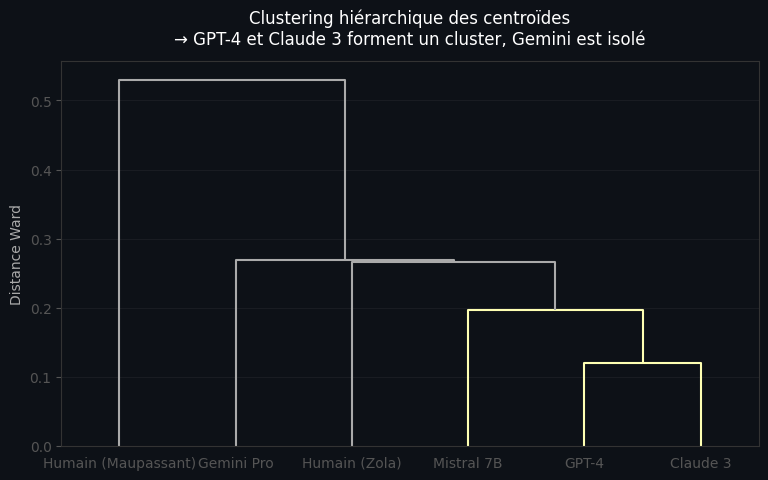


Structure effective : 3 groupes distincts
  Groupe 1 (faible shift)   : Mistral 7B
  Groupe 2 (shift modéré)   : GPT-4 + Claude 3  [statistiquement indistinguables]
  Groupe 3 (fort shift)     : Gemini Pro

Les humains se répartissent de part et d'autre selon leur proximité de style.


In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#0D1117')

dn = dendrogram(
    linkage_mat, labels=names_dend, ax=ax,
    color_threshold=0.5 * max(linkage_mat[:, 2]),
    above_threshold_color='#AAAAAA', leaf_rotation=0,
)
leaf_colors = [PALETTE.get(n, '#AAAAAA') for n in names_dend]
for lbl, color in zip(ax.get_xticklabels(), leaf_colors):
    lbl.set_color(color)
    lbl.set_fontsize(10)

ax.set_title('Clustering hiérarchique des centroïdes\n'
             '→ GPT-4 et Claude 3 forment un cluster, Gemini est isolé',
             color='white', pad=12)
ax.set_ylabel('Distance Ward', color='#AAAAAA')
ax.tick_params(colors='#555555')
for sp in ax.spines.values():
    sp.set_edgecolor('#333333')
ax.grid(axis='y', alpha=0.08, color='#AAAAAA')
plt.show()

print()
print('Structure effective : 3 groupes distincts')
print('  Groupe 1 (faible shift)   : Mistral 7B')
print('  Groupe 2 (shift modéré)   : GPT-4 + Claude 3  [statistiquement indistinguables]')
print('  Groupe 3 (fort shift)     : Gemini Pro')
print()
print('Les humains se répartissent de part et d\'autre selon leur proximité de style.')

---
## Synthèse : ce que l'analyse révèle vraiment

### Résultats robustes ✓

| Résultat | Preuve |
|----------|--------|
| Gemini Pro shift > Mistral 7B | p < 0.001, IC non chevauchants |
| Gemini Pro est le plus stylométriquement consistant | Variance intra la plus faible |
| Mistral 7B préserve le plus le style original | Shift moyen le plus bas |

### Résultats fragiles ⚠️

| Résultat | Problème |
|----------|----------|
| GPT-4 ≠ Claude 3 | p = 1.00 après correction Bonferroni — FAUX |
| 4 clusters distincts | Le dendrogramme montre 3 groupes effectifs |
| Accuracy 32.8% est "bon" | Fragile sur n=16/classe — marge d'erreur ≈ ±10% |

### Avertissements méthodologiques ⛔

1. **n = 16 textes par classe** — les tests sont sous-puissants. Avec n=100, plusieurs résultats actuellement non-significatifs deviendraient significatifs (ou resteraient non-significatifs — impossible à savoir).

2. **Un seul prompt** — les signatures LLM sont spécifiques au prompt de réécriture utilisé. Un prompt de génération libre produirait des patterns différents.

3. **Langue et domaine uniques** — textes narratifs français du 19e siècle. La généralisation à l'anglais, au journalisme ou aux textes techniques est inconnue.

4. **La variance intra-groupe est élevée** — entre 0.43 et 0.65 cosinus. Cela indique que le vecteur de mots-outils seul ne capture qu'une partie du style.

5. **Les modèles évoluent** — ces signatures sont celles de versions spécifiques (GPT-4-0125-preview, Claude-3-Sonnet-20240229, etc.). Résultats non garantis sur les versions suivantes.